In [2]:
## Plot the results from the BNNs on one graph
from __future__ import annotations

import argparse
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score

try:
    from sklearn.metrics import confusion_matrix
except ImportError as exc:  # pragma: no cover
    raise SystemExit("This script needs scikit-learn: pip install scikit-learn") from exc

In [3]:
df = pd.read_csv('echonext_metadata_100k.csv')
le = LabelEncoder()
SHD = le.fit_transform(df['shd_moderate_or_greater_flag'].values.reshape(-1,1))
id    = le.fit_transform(df['split'].values.reshape(-1,1))
id_test  = np.where(id!=2)
n_test=2000
ytest = SHD[id_test][:n_test]

print(np.shape(df))


(100000, 39)


c:\Users\colebanm\uq_disc\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\colebanm\uq_disc\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
def load_npz(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=True) as data:
        return {key: data[key] for key in data.files}

: 

: 

In [80]:

BNN_results_3_ECG = load_npz('outputs/bnn_vi_roc_results_3_10neuron_ECG_only_8000train_2000test_prior25.npz')
BNN_results_3_ECG2 = load_npz('outputs/bnn_vi_roc_results_3_10neuron_ECG_Echo_8000train_2000test_prior25.npz')
BNN_results_3_Echo = load_npz('outputs/bnn_vi_roc_results_3_10neuron_full_8000train_2000test_prior25.npz')

BNN_results_5_ECG = load_npz('outputs/bnn_vi_roc_results_5_10neuron_ECG_only_8000train_2000test_prior25.npz')
BNN_results_5_ECG2 = load_npz('outputs/bnn_vi_roc_results_5_10neuron_ECG_Echo_8000train_2000test_prior25.npz')
BNN_results_5_Echo = load_npz('outputs/bnn_vi_roc_results_5_10neuron_full_8000train_2000test_prior25.npz')


BNN_results_10_ECG = load_npz('outputs/bnn_vi_roc_results_10_10neuron_ECG_only_8000train_2000test_prior25.npz')
BNN_results_10_ECG2 = load_npz('outputs/bnn_vi_roc_results_10_10neuron_ECG_Echo_8000train_2000test_prior25.npz')
BNN_results_10_Echo = load_npz('outputs/bnn_vi_roc_results_10_10neuron_full_8000train_2000test_prior25.npz')


: 

In [83]:
def normalize_probs(probs: np.ndarray) -> np.ndarray:
    """Return posterior probabilities as shape (S,N,K), or mean probs as (N,K)."""
    probs = np.asarray(probs)

    if probs.ndim == 1:
        return np.column_stack([1.0 - probs, probs])

    if probs.ndim == 2:
        # Ambiguous: either (S,N) binary posterior samples or (N,K) mean probs.
        # Caller decides by context. Here, if columns sum roughly to 1, treat as (N,K).
        row_sums = probs.sum(axis=1)
        if probs.shape[1] > 2 and np.allclose(row_sums, 1.0, atol=1e-3):
            return probs
        if probs.shape[1] == 2 and np.allclose(row_sums, 1.0, atol=1e-3):
            return probs
        # Otherwise binary posterior samples (S,N).
        return np.stack([1.0 - probs, probs], axis=-1)

    if probs.ndim == 3:
        if probs.shape[-1] == 1:
            p = probs[..., 0]
            return np.stack([1.0 - p, p], axis=-1)
        return probs

    raise ValueError(f"Expected probability array with ndim 1, 2, or 3; got shape {probs.shape}")

# Look at posterior probabilities for random test cases
def plot_random_class_probabilities_bayesian(
    results: dict[str, np.ndarray],
    posterior_probs: np.ndarray | None,
    num_classes: int,
    title: str,
    out_path: Path,
    dpi: int,
    n_random: int,
    seed: int,
    data_ids: np.ndarray | None
) -> None:
    """
    Plot posterior PDFs of class probabilities for random test samples.

    For binary classification, each selected test sample gets its own plot with
    two PDFs: one for class 0 probability and one for class 1 probability.

    For multiclass classification, each selected test sample gets its own plot
    with one PDF per class.

    The plot title includes the true class when results contains y_true, y_test,
    true_class, true_classes, or labels.
    """
    ci_high_thresh = 0.2
    ci_low_thresh   = 0.5
    decision_out = ['No SHD','SHD','inconclusive']
    if posterior_probs is None:
        print(
            f"[skip] {title}: posterior probability samples were not saved. "
            "Need probs_samples with shape (S, N, K) to plot PDFs."
        )
        return

    p = normalize_probs(posterior_probs)

    if p.ndim != 3:
        print(f"[skip] {title}: posterior_probs could not be interpreted as shape (S,N,K).")
        return

    true_labels = None
    for key in ("y_true", "y_test", "true_class", "true_classes", "labels"):
        if key in results:
            true_labels = np.asarray(results[key])
            break

    n_samples, n_obs, inferred_num_classes = p.shape

    if true_labels is not None and len(true_labels) != n_obs:
        print(
            f"[warning] {title}: found true labels with length {len(true_labels)}, "
            f"but posterior_probs has N={n_obs}. Not using true labels in titles."
        )
        true_labels = None

    if inferred_num_classes != num_classes:
        print(
            f"[warning] {title}: num_classes={num_classes}, "
            f"but posterior_probs has K={inferred_num_classes}. Using K={inferred_num_classes}."
        )
        num_classes = inferred_num_classes

    rng = np.random.default_rng(seed)
    chosen = rng.choice(n_obs, size=min(n_random, n_obs), replace=False)
    if (len(data_ids)>0):
        chosen=rng.choice(data_ids, size=min(n_random, n_obs), replace=False)
    class_ids = np.arange(num_classes)
    for obs_idx in chosen:
        decision_plot = decision_out[0]
        BNN_pred = 0
        fig, ax = plt.subplots(figsize=(6, 4))
        for k in class_ids:
            vals = np.asarray(p[:, obs_idx, k], dtype=float)
            vals = vals[np.isfinite(vals)]

            if vals.size < 2:
                continue

            ax.hist(
                vals,
                bins=30,
                density=True,
                alpha=0.35,
                label=f"Class {decision_out[k]}",
            )

            mean_k = np.mean(vals)
            

            var_k  = np.var(vals)
            ci_low, ci_high = np.percentile(vals, [2.5, 97.5])
            if (k==1):
                if (ci_high<=ci_high_thresh):
                    decision_plot = decision_out[0]
                elif (ci_low>=ci_low_thresh):
                    decision_plot = decision_out[1]
                else:
                    decision_plot=decision_out[2]
                print(f"sample {obs_idx} class {k} has ci_high={ci_high} and ci_low={ci_low}: decision:{decision_plot}")
 


            coeff_var = mean_k/np.sqrt(var_k)

            # ax.axvline(mean_k, linestyle="--", linewidth=1.5)
            

        if true_labels is not None:
            if (true_labels[obs_idx]==0):
                true_class_text = "True class: No SHD"
            else:
                true_class_text = "True class: SHD"
        else:
            true_class_text = "True class: unavailable"

        ax.set_xlim(0, 1)
        ax.set_xlabel("Class probability")
        ax.set_ylabel("Posterior density")
        ax.axvline(ci_low_thresh, color='r',linestyle="--", linewidth=2.0,label='threshold: SHD')
        ax.axvline(ci_high_thresh, color='m',linestyle="--", linewidth=2.0, label='threshold: no SHD')
        ax.set_title(
            f"{title}\n"
            f"Test sample {obs_idx} | {true_class_text}\n"
            f"Decision: {decision_plot}"
        )
        ax.grid(True, alpha=0.10)
        ax.legend(loc="best")

        fig.tight_layout()

        sample_out_path = f"{out_path}_sample_{obs_idx}_pdfs.png"
        fig.savefig(sample_out_path, dpi=dpi)
        # plt.close(fig)

        # print(f"[saved] {sample_out_path}")





In [84]:
# Try to find where probabilities change the most
probs_stack = np.array((BNN_results_3_ECG2['probs_mean'][:,1].flatten(),BNN_results_5_ECG2['probs_mean'][:,1].flatten(),BNN_results_10_ECG2['probs_mean'][:,1].flatten()))
probs_var = np.var(probs_stack,axis=0)
probs_id = np.argsort(probs_var)
probs_id[1000:]
print(probs_stack[:,probs_id[1000:]].T)

[[0.4280274  0.38489458 0.35258216]
 [0.32283664 0.34308532 0.3961838 ]
 [0.29418677 0.36898068 0.3422048 ]
 ...
 [0.54638934 0.14111578 0.2020582 ]
 [0.598753   0.20311603 0.20879576]
 [0.5724511  0.15224846 0.20304441]]


sample 497 class 1 has ci_high=0.5410586327314376 and ci_low=0.21040492169559002: decision:inconclusive
sample 458 class 1 has ci_high=0.45760443881154056 and ci_low=0.23368015177547932: decision:inconclusive
sample 1321 class 1 has ci_high=0.7995671600103378 and ci_low=0.6232486858963966: decision:SHD
sample 24 class 1 has ci_high=0.33619580045342445 and ci_low=0.10571029465645551: decision:inconclusive


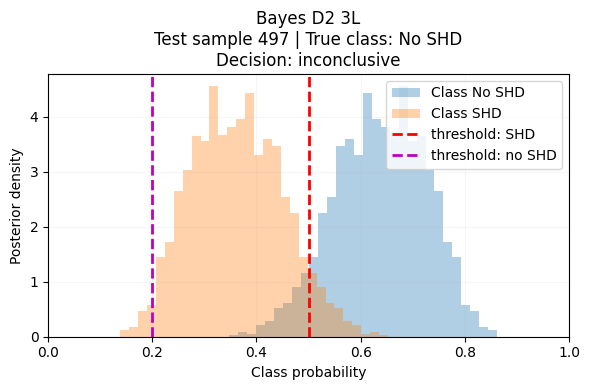

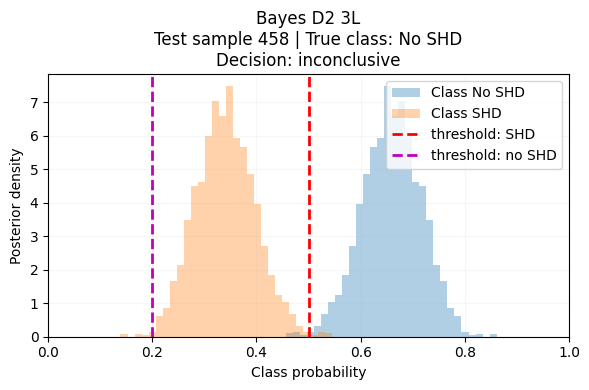

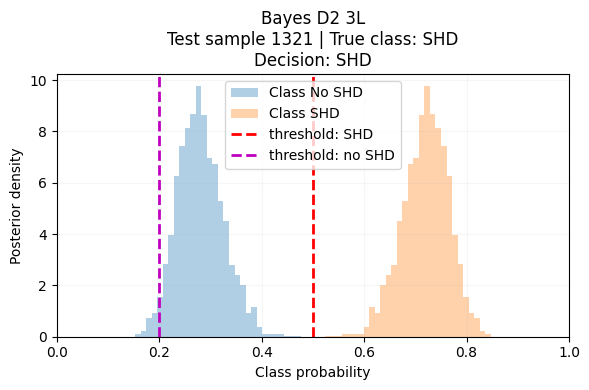

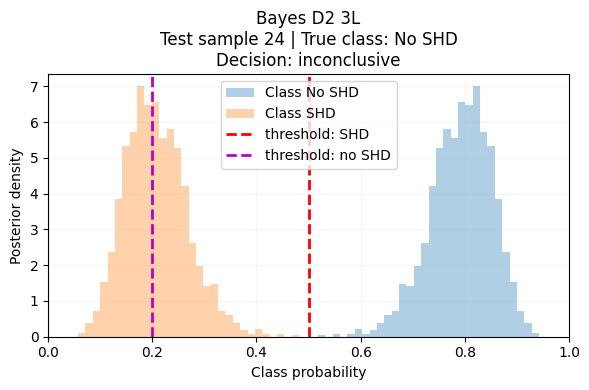

In [85]:
plot_random_class_probabilities_bayesian(results=BNN_results_3_ECG2,posterior_probs=BNN_results_3_ECG2['probs_samples'],
                                         num_classes=2,title='Bayes D2 3L',out_path='PaperFigures/BNN_8k_3layer_10neuron_prior25',dpi=200,n_random=4,seed=108,data_ids=probs_id[1000:])



sample 497 class 1 has ci_high=0.6824139922857283 and ci_low=0.2903040789067745: decision:inconclusive
sample 458 class 1 has ci_high=0.5630751132965087 and ci_low=0.2290177669376135: decision:inconclusive
sample 1321 class 1 has ci_high=0.813594204187393 and ci_low=0.4987673431634903: decision:inconclusive
sample 24 class 1 has ci_high=0.49096578583121275 and ci_low=0.1473209697753191: decision:inconclusive


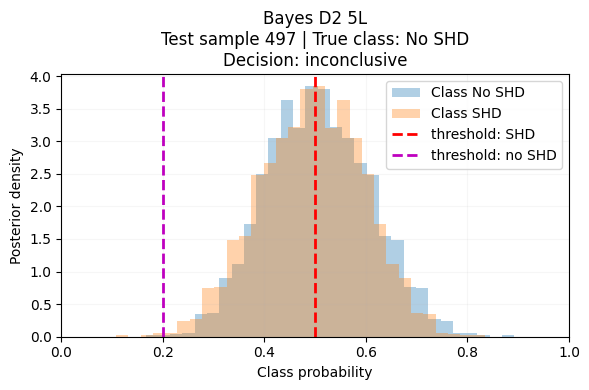

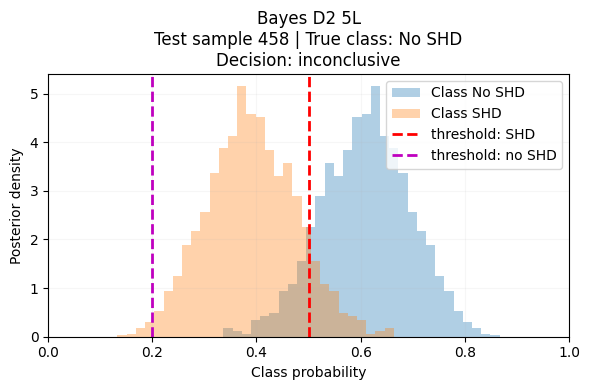

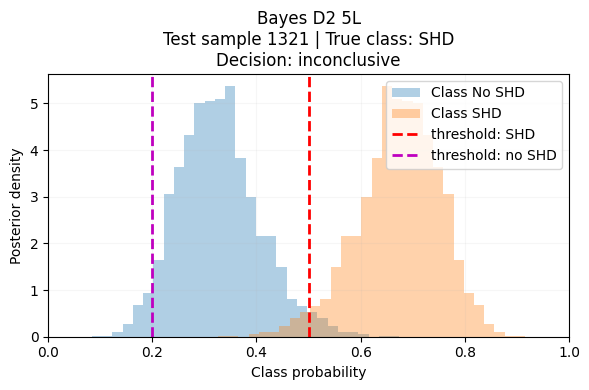

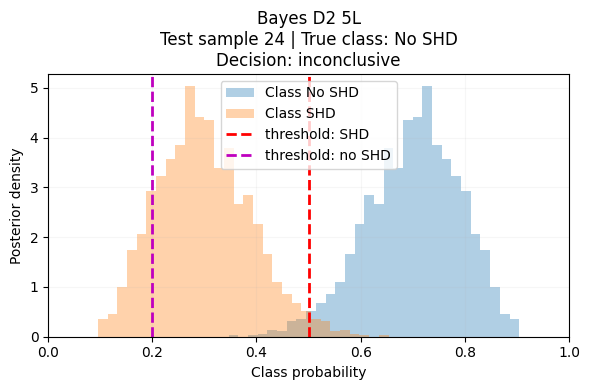

In [86]:
plot_random_class_probabilities_bayesian(results=BNN_results_5_ECG2,posterior_probs=BNN_results_5_ECG2['probs_samples'],num_classes=2,
                                         title='Bayes D2 5L',out_path='PaperFigures/BNN_8k_5layer_10neuron_prior25',dpi=200,n_random=4,seed=108,data_ids=probs_id[1000:])


sample 497 class 1 has ci_high=0.7105807304382324 and ci_low=0.21926011703908443: decision:inconclusive
sample 458 class 1 has ci_high=0.596137623488903 and ci_low=0.13051653280854225: decision:inconclusive
sample 1321 class 1 has ci_high=0.7361376360058778 and ci_low=0.31554685309529307: decision:inconclusive
sample 24 class 1 has ci_high=0.40726109147071826 and ci_low=0.11230418421328067: decision:inconclusive


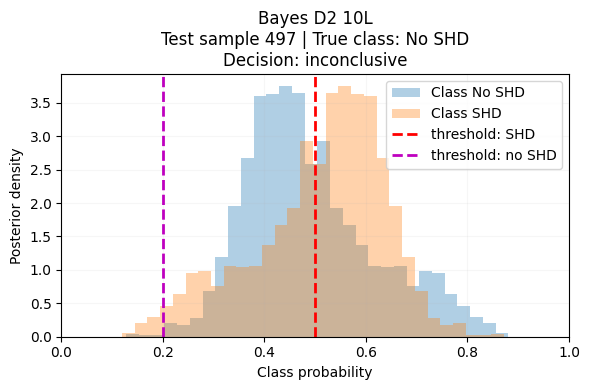

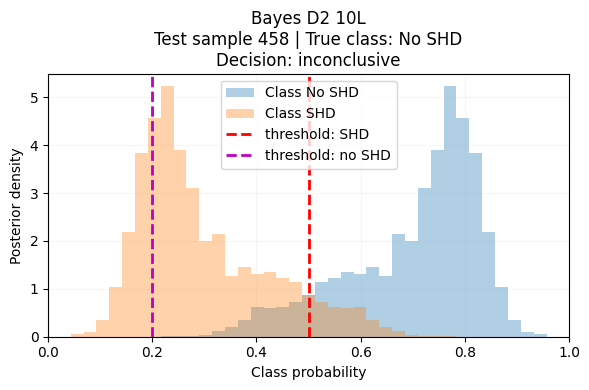

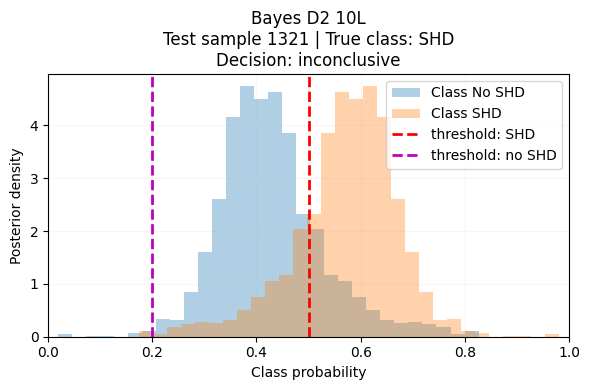

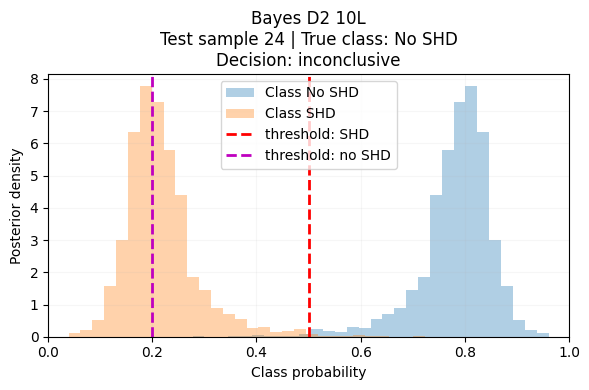

In [87]:
plot_random_class_probabilities_bayesian(results=BNN_results_10_ECG2,posterior_probs=BNN_results_10_ECG2['probs_samples'],num_classes=2,title='Bayes D2 10L',
                                         out_path='PaperFigures/BNN_8k_10layer_10neuron_prior25',dpi=200,n_random=4,seed=108,data_ids=probs_id[1000:])


In [90]:
print(np.shape(BNN_results_5_ECG2['probs_samples']))

(2000, 2000, 2)


In [88]:
import numpy as np
import matplotlib.pyplot as plt


def confusion_with_UQ(ytest, yprob,ci_noSHD_thresh,ci_SHD_thresh):
    conf_mat = np.zeros((2, 3), dtype=int)

    for i in range(len(ytest)):
        vals = np.asarray(yprob[:, i, 1], dtype=float)
        vals = vals[np.isfinite(vals)]

        if vals.size < 2:
            continue

        ci_low, ci_high = np.percentile(vals, [2.5, 97.5])

        if ci_high < ci_noSHD_thresh:
            # confidently class 0
            conf_mat[ytest[i], 0] += 1
        elif ci_low >= ci_SHD_thresh:
            # confidently class 1
            conf_mat[ytest[i], 2] += 1
        else:
            # interval crosses 0.5
            conf_mat[ytest[i], 1] += 1

    return conf_mat


def plot_uq_confusion_matrix(
    conf_mat,
    title="BNN Decision Matrix with Uncertainty",
    normalize=False,
    cmap="Blues",
    figsize=(7, 4.5),
):
    """
    Plot a 2x3 pseudo confusion matrix.

    Rows:
        0 -> true class 0
        1 -> true class 1

    Columns:
        0 -> predicted class 0 with confidence
        1 -> inconclusive
        2 -> predicted class 1 with confidence
    """
    conf_mat = np.asarray(conf_mat)

    if conf_mat.shape != (2, 3):
        raise ValueError(f"Expected conf_mat shape (2, 3), got {conf_mat.shape}")

    display_mat = conf_mat.astype(float).copy()

    if normalize:
        row_sums = display_mat.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        display_mat = display_mat / row_sums

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(display_mat, cmap=cmap, aspect="auto")

    col_labels = [
        "Pred No SHD\n(confident)",
        "Inconclusive",
        "Pred SHD\n(confident)",
    ]
    row_labels = [
        "No SHD",
        "SHD",
    ]

    ax.set_xticks(np.arange(len(col_labels)))
    ax.set_xticklabels(col_labels)
    ax.set_yticks(np.arange(len(row_labels)))
    ax.set_yticklabels(row_labels)

    ax.set_xlabel("Model decision")
    ax.set_ylabel("True class")
    ax.set_title(title)

    # Annotate cells
    thresh = display_mat.max() / 2.0 if display_mat.size > 0 else 0.0

    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            if normalize:
                text_str = f"{conf_mat[i, j]}\n({display_mat[i, j]:.1%})"
            else:
                text_str = f"{conf_mat[i, j]}"

            ax.text(
                j,
                i,
                text_str,
                ha="center",
                va="center",
                color="white" if display_mat[i, j] > thresh else "black",
                fontsize=11,
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Row-normalized proportion" if normalize else "Count")

    fig.tight_layout()
    plt.show()


def summarize_uq_confusion_matrix(conf_mat):
    """
    Print a few useful summaries from the 2x3 matrix.
    """
    conf_mat = np.asarray(conf_mat)

    if conf_mat.shape != (2, 3):
        raise ValueError(f"Expected conf_mat shape (2, 3), got {conf_mat.shape}")

    tn_conf = conf_mat[0, 0]
    fp_conf = conf_mat[0, 2]
    tp_conf = conf_mat[1, 2]
    fn_conf = conf_mat[1, 0]

    inconclusive_0 = conf_mat[0, 1]
    inconclusive_1 = conf_mat[1, 1]

    total = conf_mat.sum()
    confident_total = tn_conf + fp_conf + tp_conf + fn_conf
    inconclusive_total = inconclusive_0 + inconclusive_1

    confident_accuracy = (
        (tn_conf + tp_conf) / confident_total if confident_total > 0 else np.nan
    )
    coverage = confident_total / total if total > 0 else np.nan
    inconclusive_rate = inconclusive_total / total if total > 0 else np.nan

    print("Decision matrix summaries")
    print("-------------------------")
    print(f"Total samples           : {total}")
    print(f"Confident predictions   : {confident_total}")
    print(f"Inconclusive predictions: {inconclusive_total}")
    print(f"Coverage                : {coverage:.3f}")
    print(f"Inconclusive rate       : {inconclusive_rate:.3f}")
    print(f"Confident accuracy      : {confident_accuracy:.3f}")
    print(f"% of those undiagnosed  : {fn_conf/total:.3f}")

    print("\nCell breakdown")
    print(f"True 0 -> Pred 0 confident : {tn_conf}")
    print(f"True 0 -> Inconclusive     : {inconclusive_0}")
    print(f"True 0 -> Pred 1 confident : {fp_conf}")
    print(f"True 1 -> Pred 0 confident : {fn_conf}")
    print(f"True 1 -> Inconclusive     : {inconclusive_1}")
    print(f"True 1 -> Pred 1 confident : {tp_conf}")


# -------------------------------
# Example usage
# -------------------------------
# y_test: shape (N,)
# probs_samples: shape (S, N, 2)

# conf_mat = confusion_with_UQ(y_test, probs_samples)
# print(conf_mat)

# Raw counts
# plot_uq_confusion_matrix(
#     conf_mat,
#     title="BNN Decision Matrix",
#     normalize=False,
# )

# Row-normalized view
# plot_uq_confusion_matrix(
#     conf_mat,
#     title="BNN Decision Matrix (row-normalized)",
#     normalize=True,
# )

# Summary statistics
# summarize_uq_confusion_matrix(conf_mat)

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
C:\Users\colebanm\AppData\Local\Temp\ipykernel_42576\4000777033.py:2: SyntaxWarning: invalid escape sequence '\s'
  plot_uq_confusion_matrix(conf_mat=conf_BNN_3,title='BNN for D2: 3-Layer, 10 Neuron, $\sigma^2=0.25$')
C:\Users\colebanm\AppData\Local\Temp\ipykernel_42576\4000777033.py:6: SyntaxWarning: invalid escape sequence '\s'
  plot_uq_confusion_matrix(conf_mat=conf_BNN_5,title='BNN for D2: 5-Layer, 10 Neuron, $\sigma^2=0.25$')
C:\Users\colebanm\AppData\Local\Temp\ipykernel_42576\4000777033.py:10: SyntaxWarning: invalid escape sequence '\s'
  plot_uq_confusion_matrix(conf_mat=conf_BNN_10,title='BNN for D2: 10-Layer, 10 Neuron, $\sigma^2=0.25$')


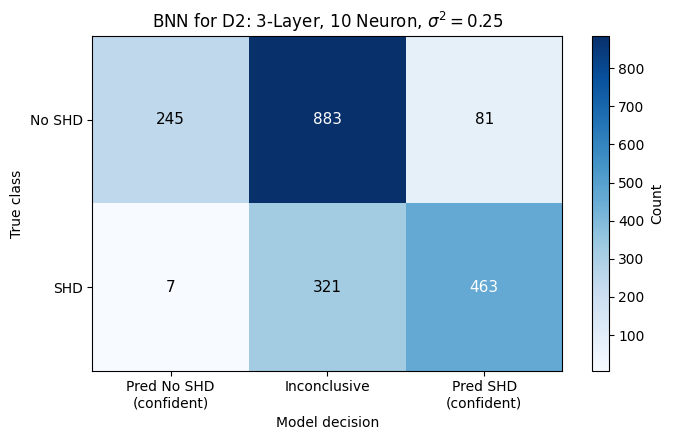

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 796
Inconclusive predictions: 1204
Coverage                : 0.398
Inconclusive rate       : 0.602
Confident accuracy      : 0.889
% of those undiagnosed  : 0.004

Cell breakdown
True 0 -> Pred 0 confident : 245
True 0 -> Inconclusive     : 883
True 0 -> Pred 1 confident : 81
True 1 -> Pred 0 confident : 7
True 1 -> Inconclusive     : 321
True 1 -> Pred 1 confident : 463


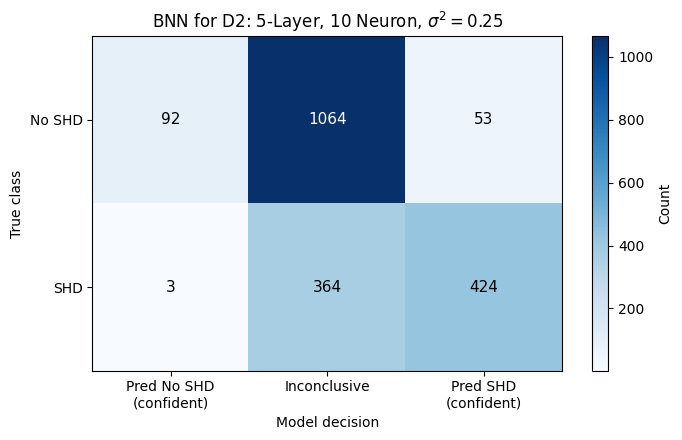

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 572
Inconclusive predictions: 1428
Coverage                : 0.286
Inconclusive rate       : 0.714
Confident accuracy      : 0.902
% of those undiagnosed  : 0.002

Cell breakdown
True 0 -> Pred 0 confident : 92
True 0 -> Inconclusive     : 1064
True 0 -> Pred 1 confident : 53
True 1 -> Pred 0 confident : 3
True 1 -> Inconclusive     : 364
True 1 -> Pred 1 confident : 424


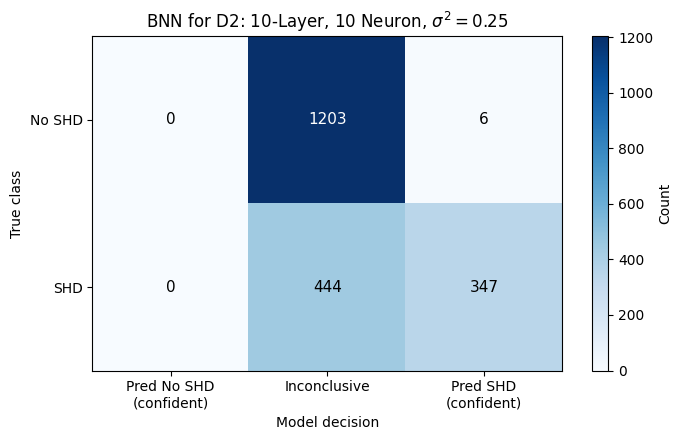

Decision matrix summaries
-------------------------
Total samples           : 2000
Confident predictions   : 353
Inconclusive predictions: 1647
Coverage                : 0.176
Inconclusive rate       : 0.824
Confident accuracy      : 0.983
% of those undiagnosed  : 0.000

Cell breakdown
True 0 -> Pred 0 confident : 0
True 0 -> Inconclusive     : 1203
True 0 -> Pred 1 confident : 6
True 1 -> Pred 0 confident : 0
True 1 -> Inconclusive     : 444
True 1 -> Pred 1 confident : 347


In [92]:
conf_BNN_3 = confusion_with_UQ(ytest=ytest,yprob=BNN_results_3_ECG2['probs_samples'],ci_noSHD_thresh=0.2,ci_SHD_thresh=0.5)
plot_uq_confusion_matrix(conf_mat=conf_BNN_3,title='BNN for D2: 3-Layer, 10 Neuron, $\sigma^2=0.25$')
summarize_uq_confusion_matrix(conf_mat=conf_BNN_3)

conf_BNN_5 = confusion_with_UQ(ytest=ytest,yprob=BNN_results_5_ECG2['probs_samples'],ci_noSHD_thresh=0.2,ci_SHD_thresh=0.5)
plot_uq_confusion_matrix(conf_mat=conf_BNN_5,title='BNN for D2: 5-Layer, 10 Neuron, $\sigma^2=0.25$')
summarize_uq_confusion_matrix(conf_mat=conf_BNN_5)

conf_BNN_10 = confusion_with_UQ(ytest=ytest,yprob=BNN_results_10_ECG2['probs_samples'],ci_noSHD_thresh=0.2,ci_SHD_thresh=0.5)
plot_uq_confusion_matrix(conf_mat=conf_BNN_10,title='BNN for D2: 10-Layer, 10 Neuron, $\sigma^2=0.25$')
summarize_uq_confusion_matrix(conf_mat=conf_BNN_10)

In [ ]:
63/2000

: 

: 